In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np

# Load the Excel file
excel_file = "labeling excel.xlsx"

# Read all sheets into a dictionary, excluding sheet 0
excel_data = pd.read_excel(excel_file, sheet_name=None)
user_sheets = {sheet_name: df for sheet_name, df in excel_data.items() if sheet_name != list(excel_data.keys())[0]}

# Print the number of users and their sheet names
print(f"Number of users: {len(user_sheets)}")
print("User sheet names:", list(user_sheets.keys()))

# Display the first few rows of one user's data for reference
sample_user = list(user_sheets.keys())[0]
print(f"\nSample data from user {sample_user}:")
print(user_sheets[sample_user].head())

Number of users: 9
User sheet names: ['Julien Issa', 'Ahmad Badruddin', 'Basel Khalil', 'Akhilanand Chaurasia', 'Rishi Ramani', 'Sarah Ehsani', 'Sara Haghighat', 'Mostafa Aldesoki', 'Faeze Dehghan']

Sample data from user Julien Issa:
       Filename  \
0  00000001.png   
1  00000002.png   
2  00000003.png   
3  00000004.png   
4  00000011.png   

   Craniocaudal (based on the guide above, you should put 1,2, or 3)  \
0                                                1.0                   
1                                                1.0                   
2                                                1.0                   
3                                                2.0                   
4                                                2.0                   

  Tooth position (based on the guide above, you should put a, b, or c)  \
0                                                NaN                     
1                                                NaN                 

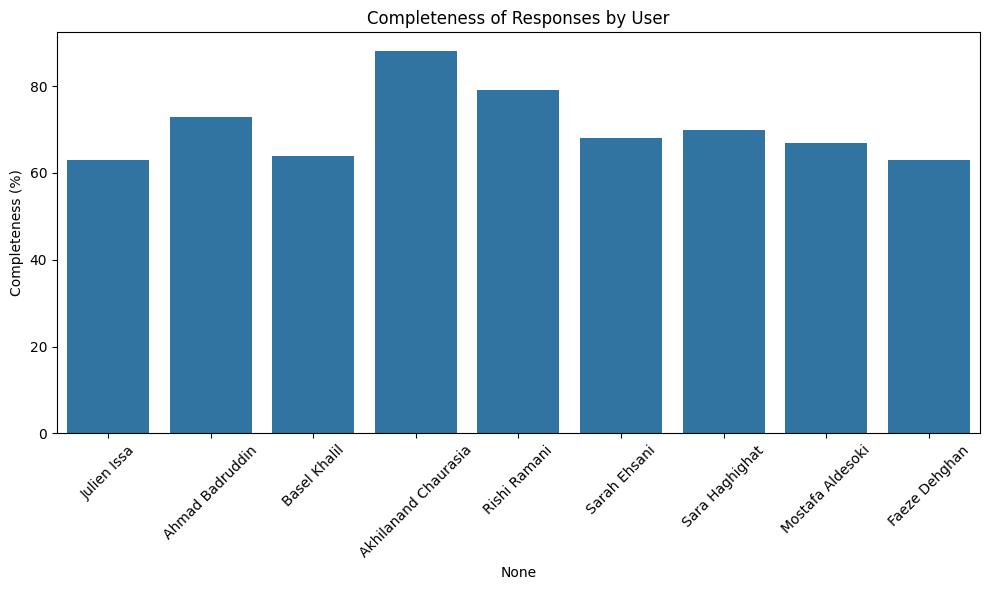


Completeness of Responses by User:
                      Completeness (%)
Akhilanand Chaurasia              88.0
Rishi Ramani                      79.0
Ahmad Badruddin                   73.0
Sara Haghighat                    70.0
Sarah Ehsani                      68.0
Mostafa Aldesoki                  67.0
Basel Khalil                      64.0
Julien Issa                       63.0
Faeze Dehghan                     63.0


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming user_sheets from Step 1 is available
# Initialize a dictionary to store completeness metrics
completeness = {}

# Columns to check for completeness
key_columns = ['Craniocaudal (based on the guide above, you should put 1,2, or 3)',
               'Tooth position (based on the guide above, you should put a, b, or c)']

for user, df in user_sheets.items():
    total_entries = len(df) * len(key_columns)
    non_empty = df[key_columns].notna().sum().sum()
    completeness_percentage = (non_empty / total_entries) * 100
    completeness[user] = completeness_percentage

# Convert to DataFrame for visualization
completeness_df = pd.DataFrame.from_dict(completeness, orient='index', columns=['Completeness (%)'])

# Plot completeness
plt.figure(figsize=(10, 6))
sns.barplot(x=completeness_df.index, y=completeness_df['Completeness (%)'])
plt.title('Completeness of Responses by User')
plt.xticks(rotation=45)
plt.ylabel('Completeness (%)')
plt.tight_layout()
plt.show()

# Display completeness table
print("\nCompleteness of Responses by User:")
print(completeness_df.sort_values(by='Completeness (%)', ascending=False))

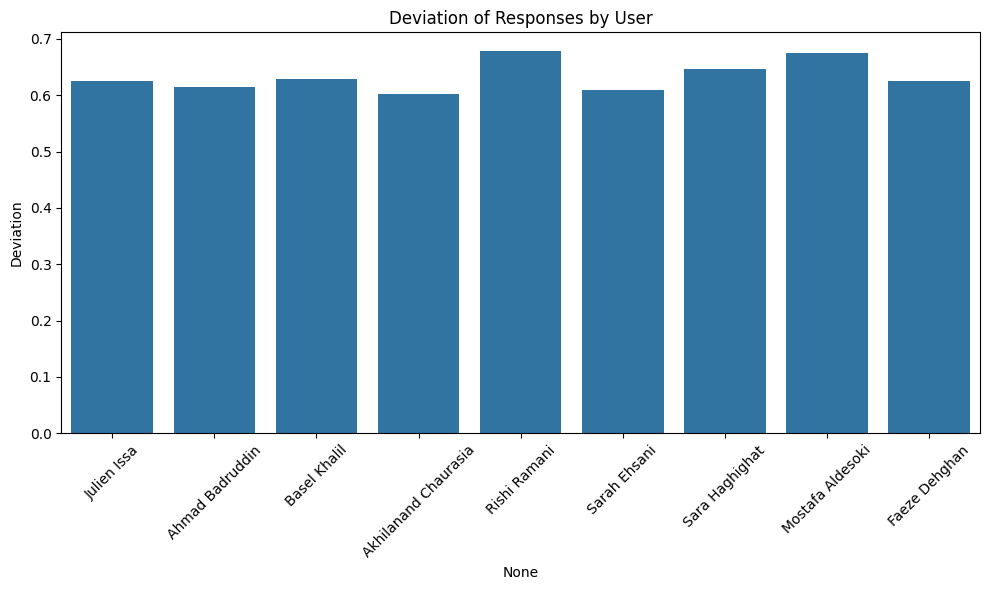

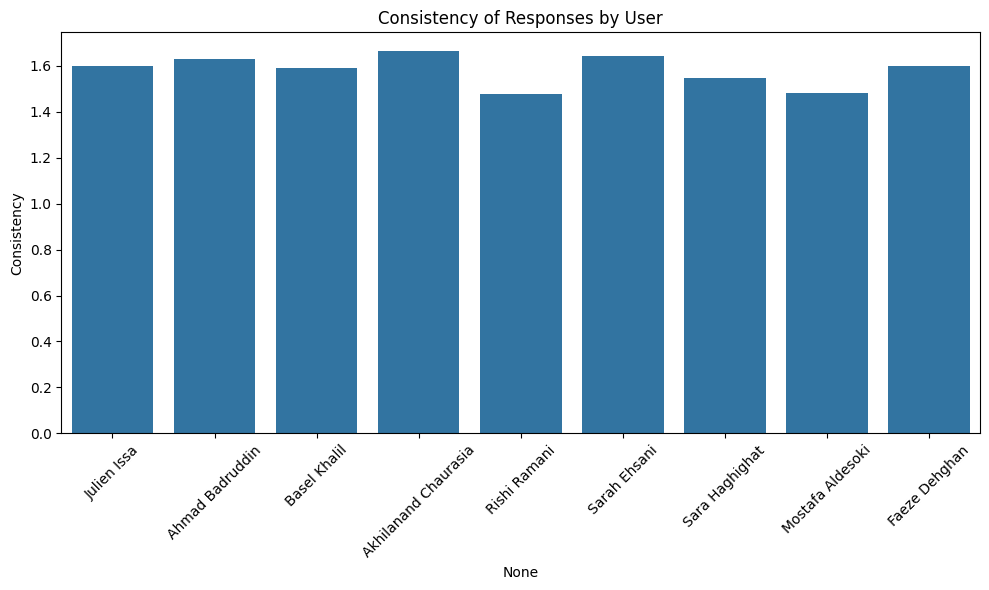


Deviation of Responses by User:
                      Deviation
Akhilanand Chaurasia   0.601267
Sarah Ehsani           0.609114
Ahmad Badruddin        0.614120
Julien Issa            0.625227
Faeze Dehghan          0.625227
Basel Khalil           0.628768
Sara Haghighat         0.646813
Mostafa Aldesoki       0.674915
Rishi Ramani           0.677631

Consistency of Responses by User:
                      Consistency
Akhilanand Chaurasia     1.663154
Sarah Ehsani             1.641728
Ahmad Badruddin          1.628347
Julien Issa              1.599418
Faeze Dehghan            1.599418
Basel Khalil             1.590412
Sara Haghighat           1.546041
Mostafa Aldesoki         1.481668
Rishi Ramani             1.475730


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
excel_file = "labeling excel.xlsx"

# Read all sheets into a dictionary, excluding sheet 0
excel_data = pd.read_excel(excel_file, sheet_name=None, engine='openpyxl')
user_sheets = {sheet_name: df for sheet_name, df in excel_data.items() if sheet_name != list(excel_data.keys())[0]}

# Initialize dictionaries to store deviation and consistency metrics
deviation = {}
consistency = {}

# Column to analyze
craniocaudal_col = 'Craniocaudal (based on the guide above, you should put 1,2, or 3)'

# Calculate deviation and consistency
for user, df in user_sheets.items():
    std_dev = df[craniocaudal_col].std()
    deviation[user] = std_dev
    consistency[user] = 1 / std_dev if std_dev != 0 else np.inf

# Convert to DataFrames
deviation_df = pd.DataFrame.from_dict(deviation, orient='index', columns=['Deviation'])
consistency_df = pd.DataFrame.from_dict(consistency, orient='index', columns=['Consistency'])

# Plot deviation
plt.figure(figsize=(10, 6))
sns.barplot(x=deviation_df.index, y=deviation_df['Deviation'])
plt.title('Deviation of Responses by User')
plt.xticks(rotation=45)
plt.ylabel('Deviation')
plt.tight_layout()
plt.show()

# Plot consistency
plt.figure(figsize=(10, 6))
sns.barplot(x=consistency_df.index, y=consistency_df['Consistency'])
plt.title('Consistency of Responses by User')
plt.xticks(rotation=45)
plt.ylabel('Consistency')
plt.tight_layout()
plt.show()

# Print tables
print("\nDeviation of Responses by User:")
print(deviation_df.sort_values(by='Deviation'))

print("\nConsistency of Responses by User:")
print(consistency_df.sort_values(by='Consistency', ascending=False))


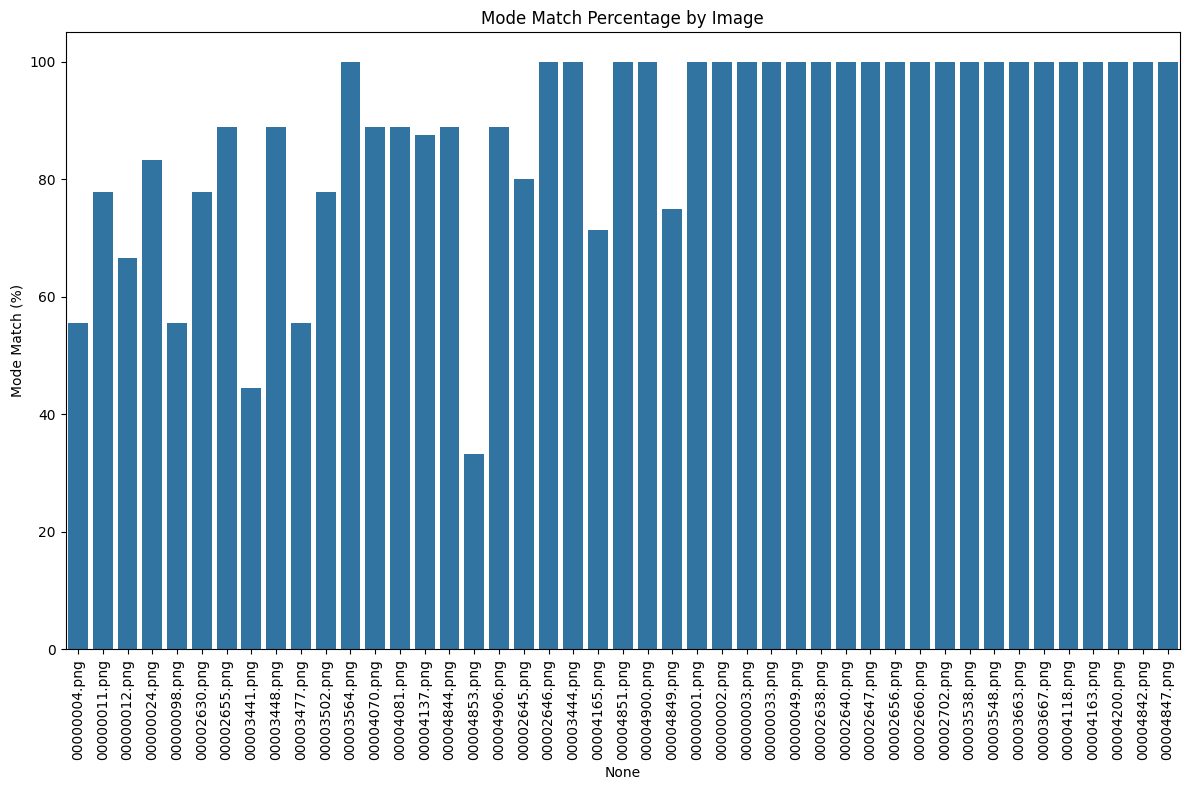

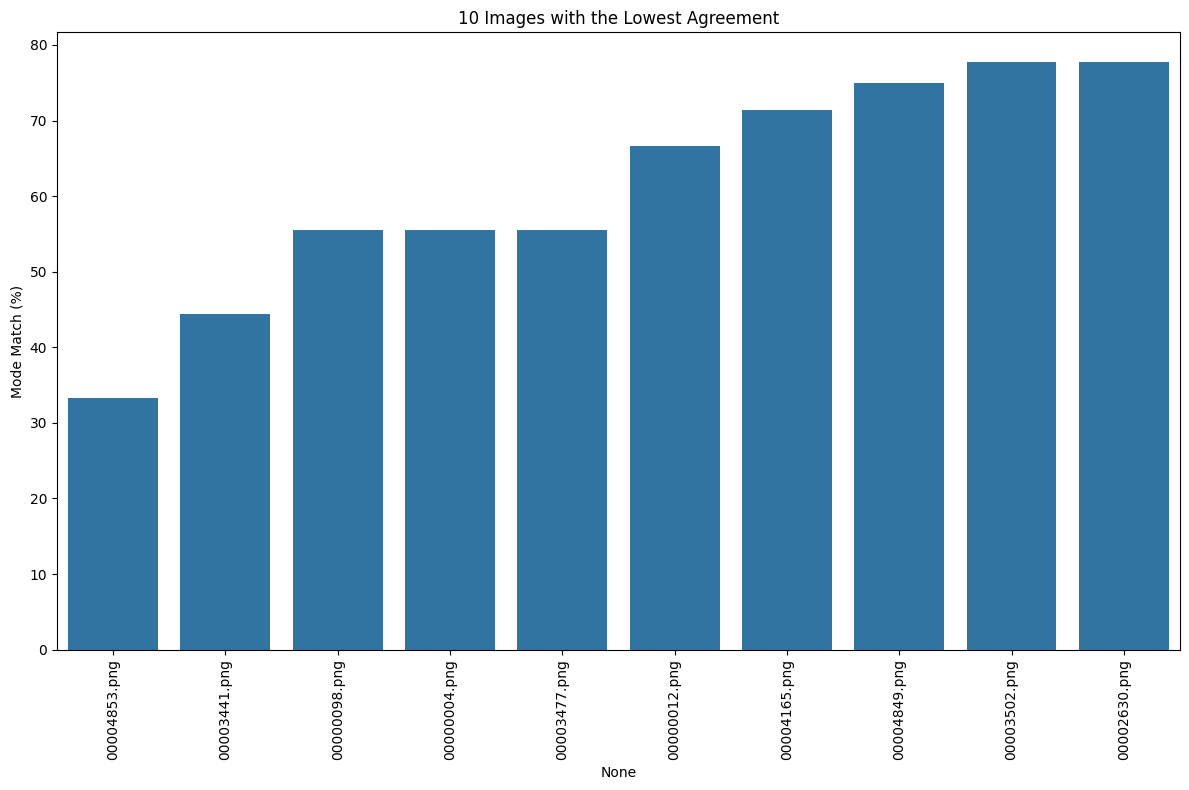


Mode Match Percentage by Image:
              Mode Match (%)
00003564.png      100.000000
00002656.png      100.000000
00002660.png      100.000000
00002702.png      100.000000
00003538.png      100.000000
00004851.png      100.000000
00004900.png      100.000000
00000002.png      100.000000
00000001.png      100.000000
00000003.png      100.000000
00000033.png      100.000000
00003444.png      100.000000
00002646.png      100.000000
00003548.png      100.000000
00003663.png      100.000000
00003667.png      100.000000
00004118.png      100.000000
00004163.png      100.000000
00004200.png      100.000000
00004842.png      100.000000
00004847.png      100.000000
00002647.png      100.000000
00002640.png      100.000000
00002638.png      100.000000
00000049.png      100.000000
00004081.png       88.888889
00002655.png       88.888889
00004070.png       88.888889
00003448.png       88.888889
00004844.png       88.888889
00004906.png       88.888889
00004137.png       87.500000
00000024.p

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Load the Excel file
excel_file = "labeling excel.xlsx"

# Read all sheets into a dictionary, excluding sheet 0
excel_data = pd.read_excel(excel_file, sheet_name=None, engine='openpyxl')
user_sheets = {sheet_name: df for sheet_name, df in excel_data.items() if sheet_name != list(excel_data.keys())[0]}

# Step 4: Calculate mode match percentage for each image
mode_match = defaultdict(list)

for user, df in user_sheets.items():
    for idx, row in df.iterrows():
        filename = row['Filename']
        tooth_position = row['Tooth position (based on the guide above, you should put a, b, or c)']
        if pd.notna(tooth_position):
            mode_match[filename].append(tooth_position)

mode_match_percentage = {}
for filename, positions in mode_match.items():
    if positions:
        most_common = max(set(positions), key=positions.count)
        mode_count = positions.count(most_common)
        mode_match_percentage[filename] = (mode_count / len(positions)) * 100

mode_match_df = pd.DataFrame.from_dict(mode_match_percentage, orient='index', columns=['Mode Match (%)'])

# Plot mode match percentage
plt.figure(figsize=(12, 8))
sns.barplot(x=mode_match_df.index, y=mode_match_df['Mode Match (%)'])
plt.title('Mode Match Percentage by Image')
plt.xticks(rotation=90)
plt.ylabel('Mode Match (%)')
plt.tight_layout()
plt.show()

# Step 5: Identify 10 images with the lowest agreement
lowest_agreement_df = mode_match_df.sort_values(by='Mode Match (%)').head(10)

# Plot lowest agreement images
plt.figure(figsize=(12, 8))
sns.barplot(x=lowest_agreement_df.index, y=lowest_agreement_df['Mode Match (%)'])
plt.title('10 Images with the Lowest Agreement')
plt.xticks(rotation=90)
plt.ylabel('Mode Match (%)')
plt.tight_layout()
plt.show()

# Display tables
print("\nMode Match Percentage by Image:")
print(mode_match_df.sort_values(by='Mode Match (%)', ascending=False))

print("\n10 Images with the Lowest Agreement:")
print(lowest_agreement_df)



Step A: Inter-user agreement matrix for 'Craniocaudal' and 'Tooth position'

Craniocaudal Agreement Matrix:
                      Julien Issa  Ahmad Badruddin  Basel Khalil  \
Julien Issa                   NaN        82.222222     90.476190   
Ahmad Badruddin         82.222222              NaN     84.090909   
Basel Khalil            90.476190        84.090909           NaN   
Akhilanand Chaurasia    85.714286        68.181818     80.952381   
Rishi Ramani            73.333333        78.000000     77.272727   
Sarah Ehsani            97.777778        82.000000     90.909091   
Sara Haghighat          86.666667        82.000000     86.363636   
Mostafa Aldesoki        86.666667        84.000000     86.363636   
Faeze Dehghan          100.000000        82.222222     90.476190   

                      Akhilanand Chaurasia  Rishi Ramani  Sarah Ehsani  \
Julien Issa                      85.714286     73.333333     97.777778   
Ahmad Badruddin                  68.181818     78.000000     8

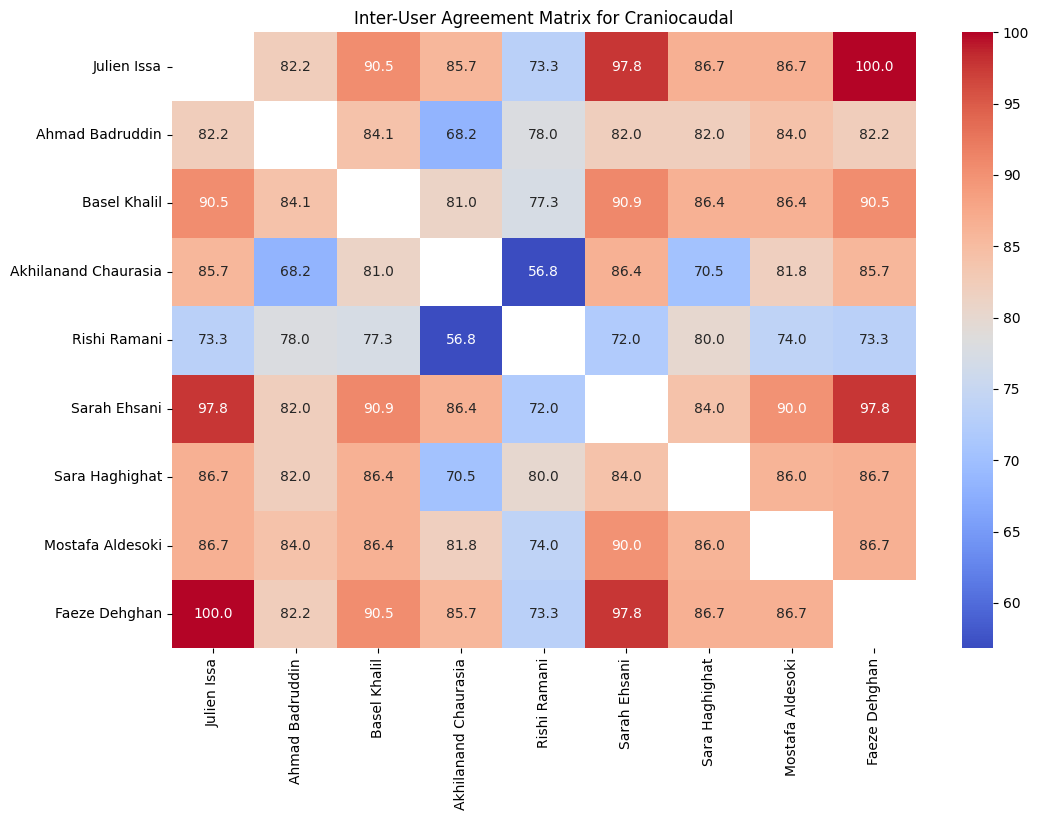

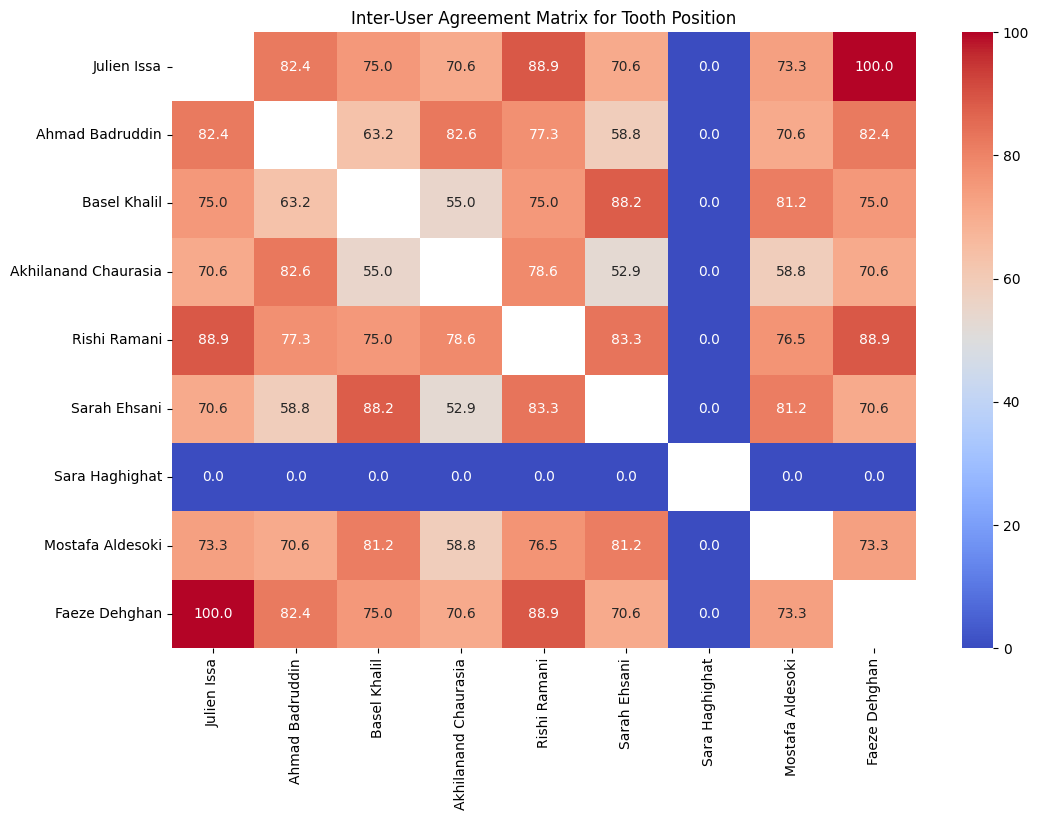


Step B: Label distribution per user for 'Craniocaudal' and 'Tooth position'

Craniocaudal Label Distribution:
                                                    Julien Issa  \
Craniocaudal (based on the guide above, you sho...                
1.0                                                   60.000000   
2.0                                                   33.333333   
3.0                                                    6.666667   

                                                    Ahmad Badruddin  \
Craniocaudal (based on the guide above, you sho...                    
1.0                                                            54.0   
2.0                                                            40.0   
3.0                                                             6.0   

                                                    Basel Khalil  \
Craniocaudal (based on the guide above, you sho...                 
1.0                                                    56.818

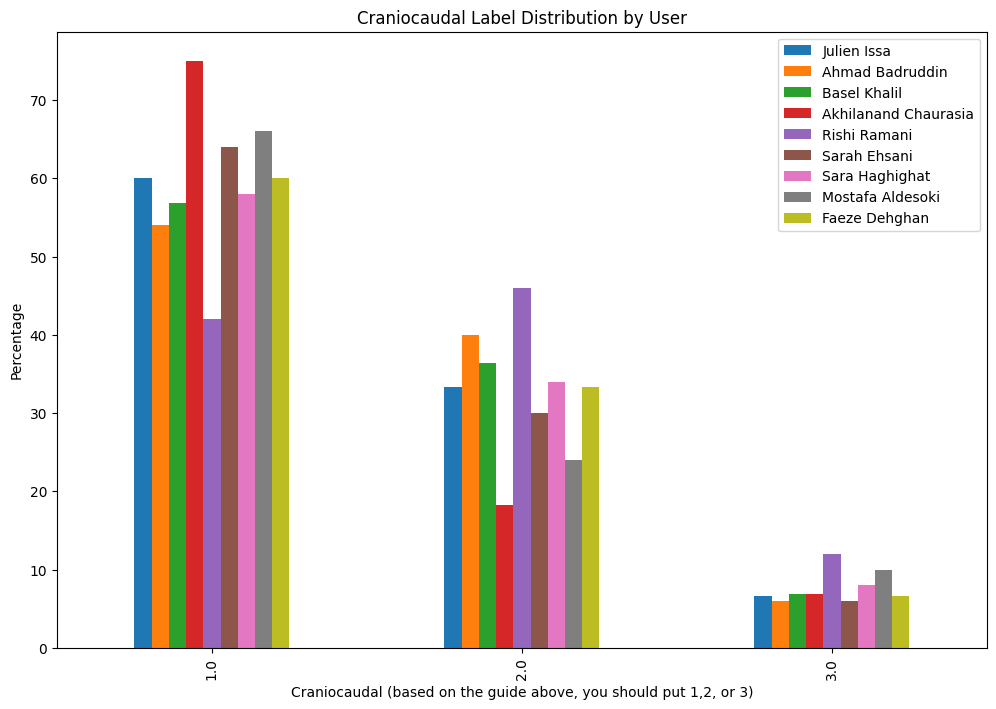

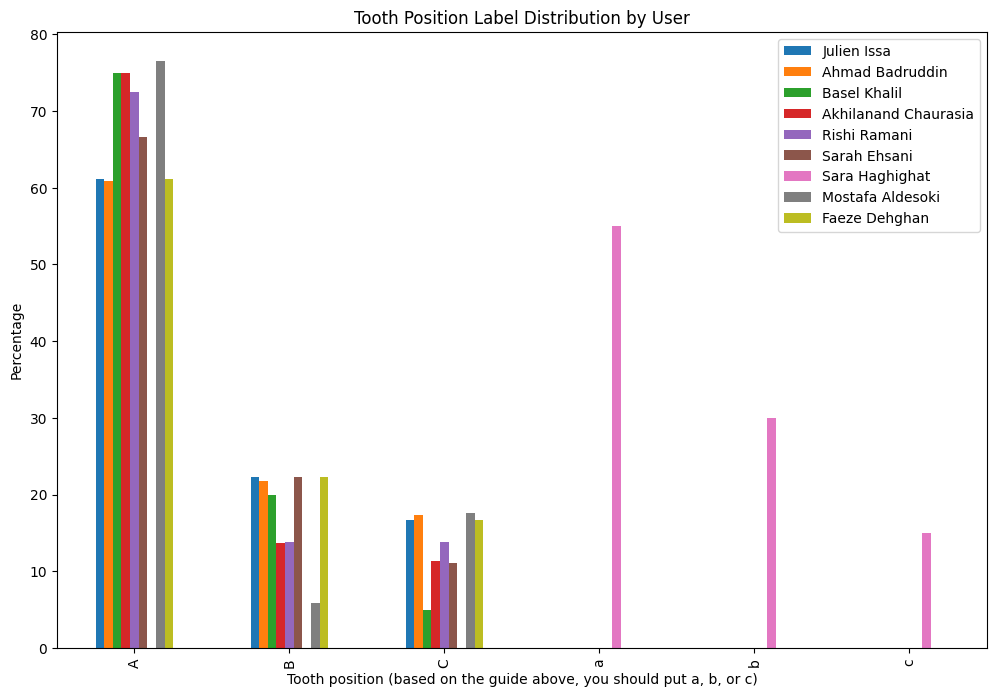


Step C: Analysis of 'Double-check needed' flag usage per user

Double-check Flag Usage:
                      Double-check Count
Julien Issa                          1.0
Ahmad Badruddin                      0.0
Basel Khalil                         0.0
Akhilanand Chaurasia                 4.0
Rishi Ramani                         4.0
Sarah Ehsani                        12.0
Sara Haghighat                       1.0
Mostafa Aldesoki                     1.0
Faeze Dehghan                        1.0


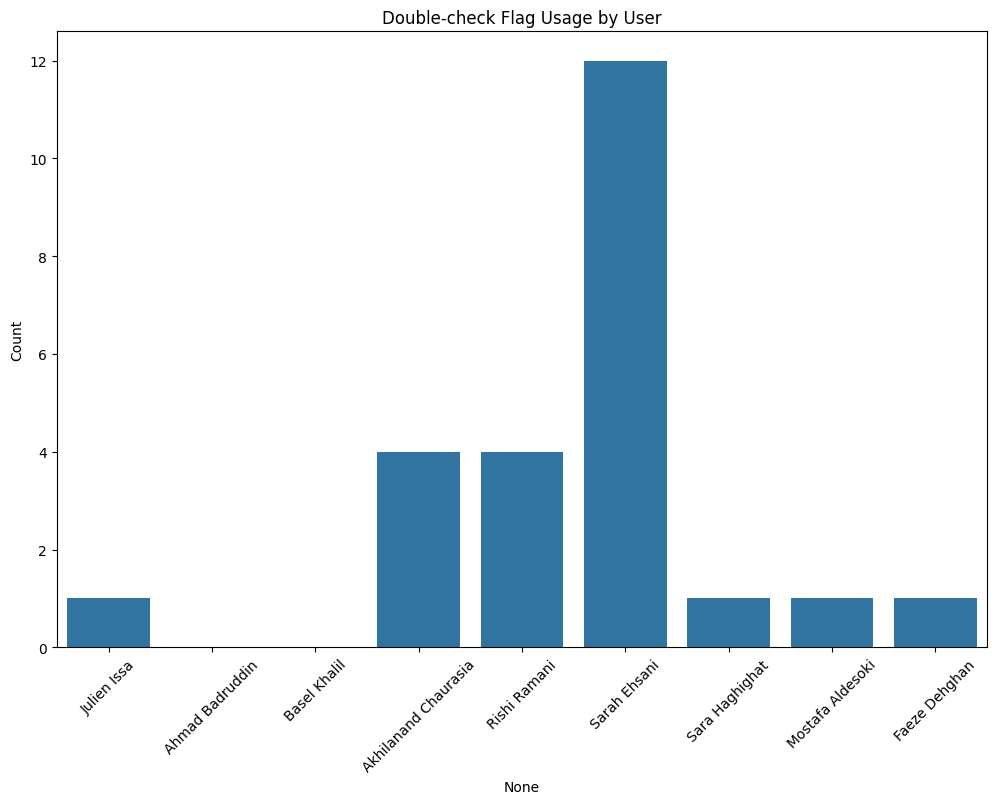


Step D: Analysis of 'Low quality' and 'Root incompletion' flags per user

Low Quality Flag Usage:
                      Low Quality Count
Julien Issa                         3.0
Ahmad Badruddin                     3.0
Basel Khalil                        3.0
Akhilanand Chaurasia                3.0
Rishi Ramani                        9.0
Sarah Ehsani                        7.0
Sara Haghighat                      0.0
Mostafa Aldesoki                    5.0
Faeze Dehghan                       3.0

Root Incompletion Flag Usage:
                      Root Incompletion Count
Julien Issa                               3.0
Ahmad Badruddin                           4.0
Basel Khalil                              4.0
Akhilanand Chaurasia                      3.0
Rishi Ramani                              7.0
Sarah Ehsani                              6.0
Sara Haghighat                            7.0
Mostafa Aldesoki                          4.0
Faeze Dehghan                             3.0


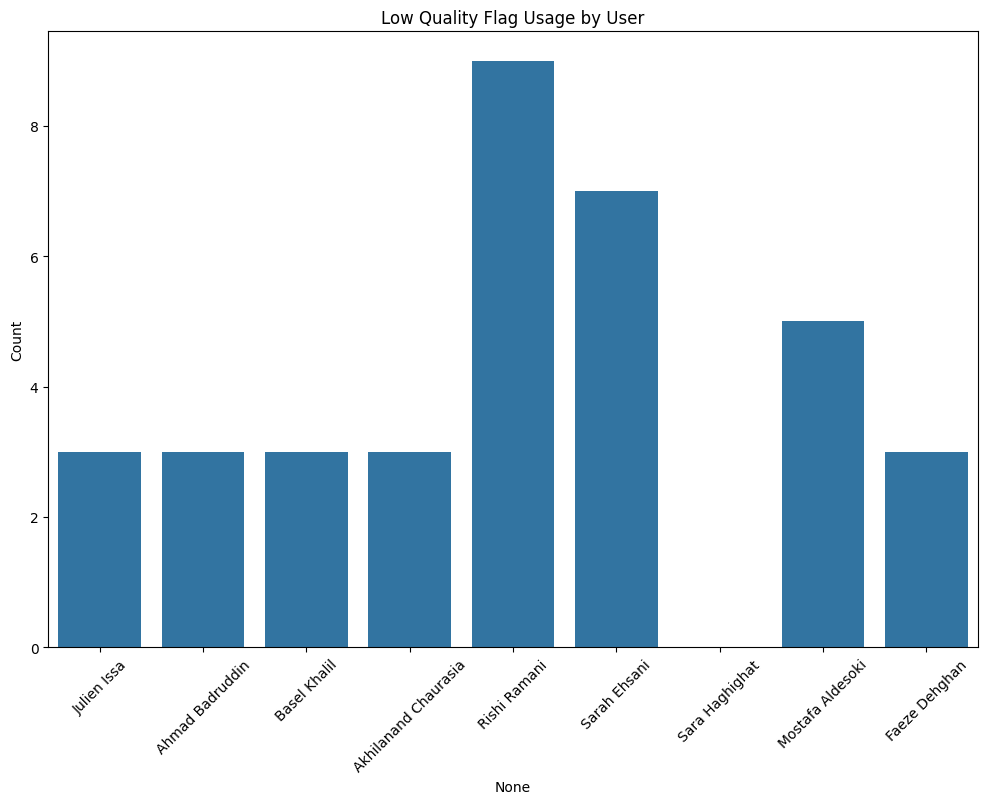

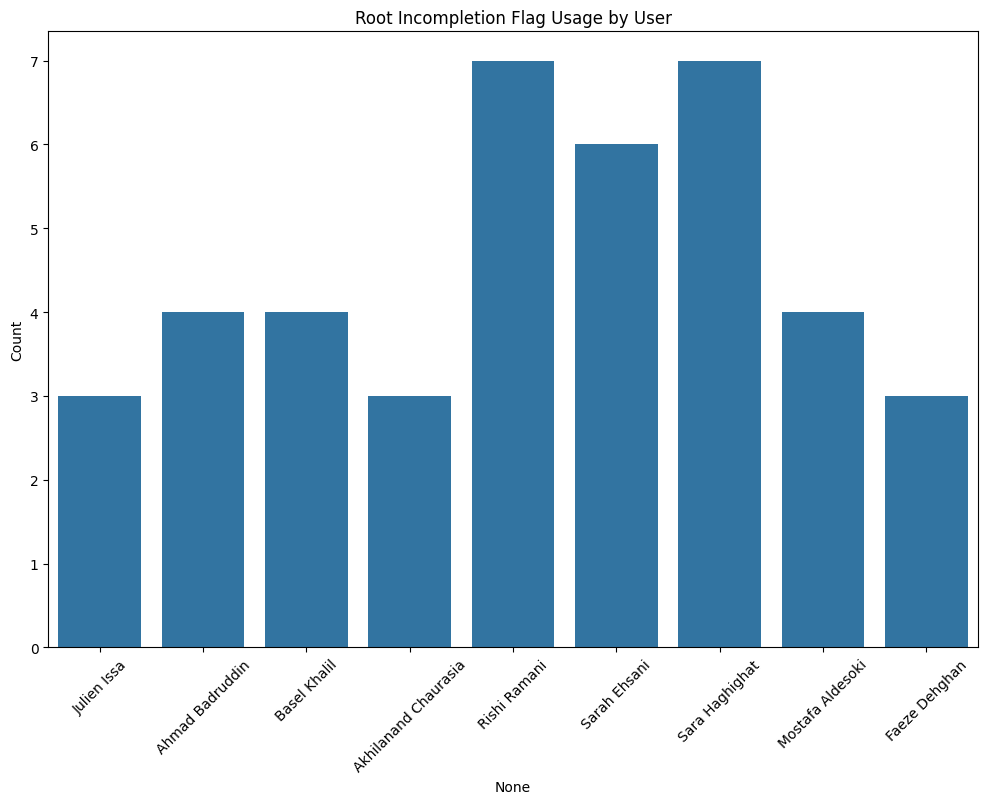

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Load the Excel file
excel_file = "labeling excel.xlsx"

# Read all sheets into a dictionary, excluding sheet 0
excel_data = pd.read_excel(excel_file, sheet_name=None, engine='openpyxl')
user_sheets = {sheet_name: df for sheet_name, df in excel_data.items() if sheet_name != list(excel_data.keys())[0]}

# Step A: Inter-user agreement matrix for 'Craniocaudal' and 'Tooth position'
print("\nStep A: Inter-user agreement matrix for 'Craniocaudal' and 'Tooth position'")

def agreement_matrix(column):
    users = list(user_sheets.keys())
    matrix = pd.DataFrame(index=users, columns=users, dtype=float)

    for user1 in users:
        for user2 in users:
            if user1 != user2:
                df1 = user_sheets[user1][['Filename', column]].dropna()
                df2 = user_sheets[user2][['Filename', column]].dropna()
                merged = pd.merge(df1, df2, on='Filename', suffixes=('_1', '_2'))
                agreement = (merged[f'{column}_1'] == merged[f'{column}_2']).mean()
                matrix.loc[user1, user2] = agreement * 100

    return matrix

craniocaudal_agreement = agreement_matrix('Craniocaudal (based on the guide above, you should put 1,2, or 3)')
tooth_position_agreement = agreement_matrix('Tooth position (based on the guide above, you should put a, b, or c)')

print("\nCraniocaudal Agreement Matrix:")
print(craniocaudal_agreement)

print("\nTooth Position Agreement Matrix:")
print(tooth_position_agreement)

plt.figure(figsize=(12, 8))
sns.heatmap(craniocaudal_agreement, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Inter-User Agreement Matrix for Craniocaudal')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(tooth_position_agreement, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Inter-User Agreement Matrix for Tooth Position')
plt.show()

# Step B: Label distribution per user for both columns
print("\nStep B: Label distribution per user for 'Craniocaudal' and 'Tooth position'")

def label_distribution(column):
    distribution = {}
    for user, df in user_sheets.items():
        distribution[user] = df[column].value_counts(normalize=True) * 100
    return pd.DataFrame(distribution).fillna(0)

craniocaudal_distribution = label_distribution('Craniocaudal (based on the guide above, you should put 1,2, or 3)')
tooth_position_distribution = label_distribution('Tooth position (based on the guide above, you should put a, b, or c)')

print("\nCraniocaudal Label Distribution:")
print(craniocaudal_distribution)

print("\nTooth Position Label Distribution:")
print(tooth_position_distribution)

craniocaudal_distribution.plot(kind='bar', figsize=(12, 8), title='Craniocaudal Label Distribution by User')
plt.ylabel('Percentage')
plt.show()

tooth_position_distribution.plot(kind='bar', figsize=(12, 8), title='Tooth Position Label Distribution by User')
plt.ylabel('Percentage')
plt.show()

# Step C: Analysis of 'Double-check needed' flag usage per user
print("\nStep C: Analysis of 'Double-check needed' flag usage per user")

double_check_usage = {}
for user, df in user_sheets.items():
    double_check_usage[user] = df['Double-check needed (Put 1 if you think it needs to be double-checked)'].sum()

double_check_df = pd.DataFrame.from_dict(double_check_usage, orient='index', columns=['Double-check Count'])

print("\nDouble-check Flag Usage:")
print(double_check_df)

plt.figure(figsize=(12, 8))
sns.barplot(x=double_check_df.index, y=double_check_df['Double-check Count'])
plt.title('Double-check Flag Usage by User')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

# Step D: Analysis of 'Low quality' and 'Root incompletion' flags per user
print("\nStep D: Analysis of 'Low quality' and 'Root incompletion' flags per user")

low_quality_usage = {}
root_incompletion_usage = {}

for user, df in user_sheets.items():
    low_quality_usage[user] = df['Low quality (put 1 if the image is low quality, otherwise leave it empty)'].sum()
    root_incompletion_usage[user] = df['Root incompletion (put 1 if the tooth roots are not completely evolved, otherwise leave it empty)'].sum()

low_quality_df = pd.DataFrame.from_dict(low_quality_usage, orient='index', columns=['Low Quality Count'])
root_incompletion_df = pd.DataFrame.from_dict(root_incompletion_usage, orient='index', columns=['Root Incompletion Count'])

print("\nLow Quality Flag Usage:")
print(low_quality_df)

print("\nRoot Incompletion Flag Usage:")
print(root_incompletion_df)

plt.figure(figsize=(12, 8))
sns.barplot(x=low_quality_df.index, y=low_quality_df['Low Quality Count'])
plt.title('Low Quality Flag Usage by User')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 8))
sns.barplot(x=root_incompletion_df.index, y=root_incompletion_df['Root Incompletion Count'])
plt.title('Root Incompletion Flag Usage by User')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

